Task 2

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

In [2]:
# створюємо початкову матрицю 26x26 з випадковими 0 і 1
random.seed(42)
grid = [[random.randint(0, 1) for _ in range(26)] for _ in range(26)]
initial_grid = [row[:] for row in grid]  # копія для візуалізації
print(f'Initial grid: {sum(sum(row) for row in grid)} alive cells')

Initial grid: 334 alive cells


In [3]:
def step(grid):
    """один крок симуляції за правилами Conway"""
    new_grid = [[0] * 26 for _ in range(26)]
    
    # 8 напрямків для сусідів
    directions = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1),
    ]

    for row in range(26):
        for col in range(26):
            # рахуємо живих сусідів
            live_neighbors = 0
            for dr, dc in directions:
                r = row + dr
                c = col + dc
                if 0 <= r < 26 and 0 <= c < 26:
                    live_neighbors += grid[r][c]

            # застосовуємо правила
            if grid[row][col] == 1:
                # жива клітина виживає якщо 2-3 сусіди
                new_grid[row][col] = 1 if live_neighbors in (2, 3) else 0
            else:
                # мертва оживає якщо рівно 3 сусіди
                new_grid[row][col] = 1 if live_neighbors == 3 else 0

    return new_grid


def run_game(grid, steps=20):
    """запускає гру на задану кількість кроків"""
    history = [grid]
    for i in range(steps):
        grid = step(grid)
        history.append(grid)
        alive = sum(sum(row) for row in grid)
        print(f'Step {i+1}: {alive} alive cells')
    return history

In [4]:
# запускаємо симуляцію на 20 кроків
history = run_game(grid, steps=20)

final_grid = history[-1]
print(f'\nFinal grid after 20 steps:')
for row in final_grid:
    print(''.join(['█' if c else '·' for c in row]))

Step 1: 185 alive cells
Step 2: 168 alive cells
Step 3: 147 alive cells
Step 4: 133 alive cells
Step 5: 131 alive cells
Step 6: 117 alive cells
Step 7: 102 alive cells
Step 8: 112 alive cells
Step 9: 100 alive cells
Step 10: 109 alive cells
Step 11: 100 alive cells
Step 12: 109 alive cells
Step 13: 91 alive cells
Step 14: 85 alive cells
Step 15: 77 alive cells
Step 16: 80 alive cells
Step 17: 87 alive cells
Step 18: 80 alive cells
Step 19: 83 alive cells
Step 20: 88 alive cells

Final grid after 20 steps:
··········██··············
·······█····█·············
···███·██···█·············
···██·█·····█·············
···███·█·███····██······██
·······█·██··██··█····█·█·
·······█···█·····█····███·
···········█····█······█··
······█·█···█··█··········
·····██·██················
······███·················
··························
············██············
············██············
··························
··························
················██········
···███··········██········
···

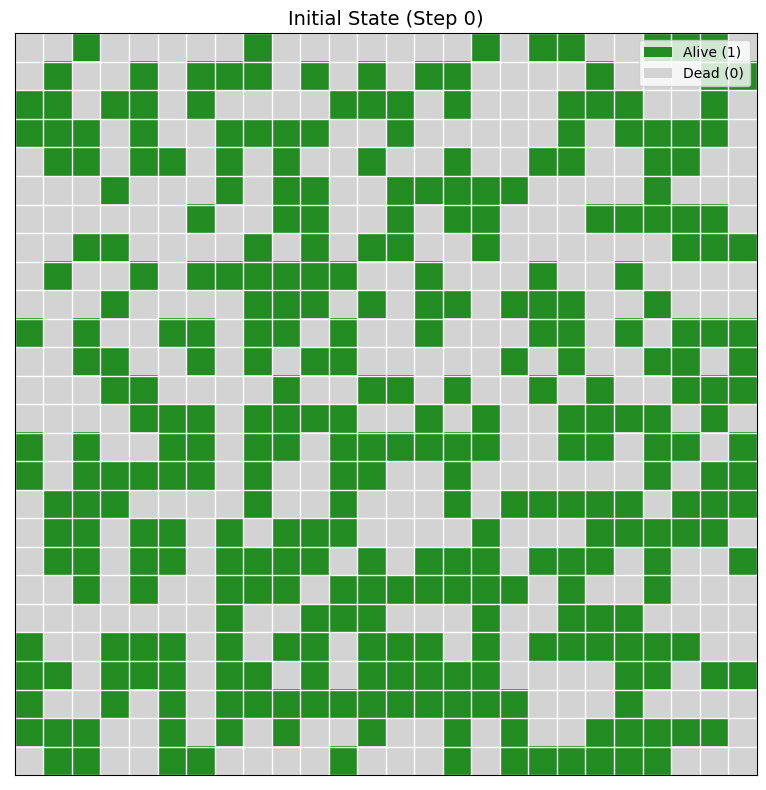

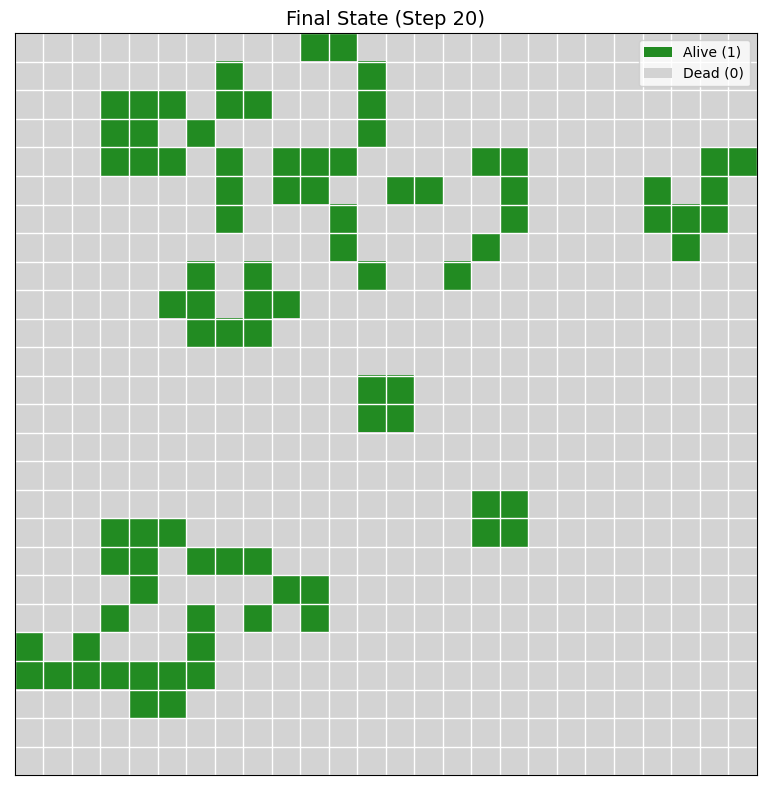

In [5]:
def plot_grid(grid, title='Game of Life'):
    """відображає стан гри як кольорову сітку"""
    cmap = mcolors.ListedColormap(['#D3D3D3', '#228B22'])  # сірий і зелений
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=1)

    # малюємо лінії сітки
    for i in range(27):
        ax.axhline(i - 0.5, color='white', linewidth=1)
        ax.axvline(i - 0.5, color='white', linewidth=1)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14)
    legend = [Patch(facecolor='#228B22', label='Alive (1)'),
              Patch(facecolor='#D3D3D3', label='Dead (0)')]
    ax.legend(handles=legend, loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

plot_grid(initial_grid, 'Initial State (Step 0)')
plot_grid(final_grid, 'Final State (Step 20)')

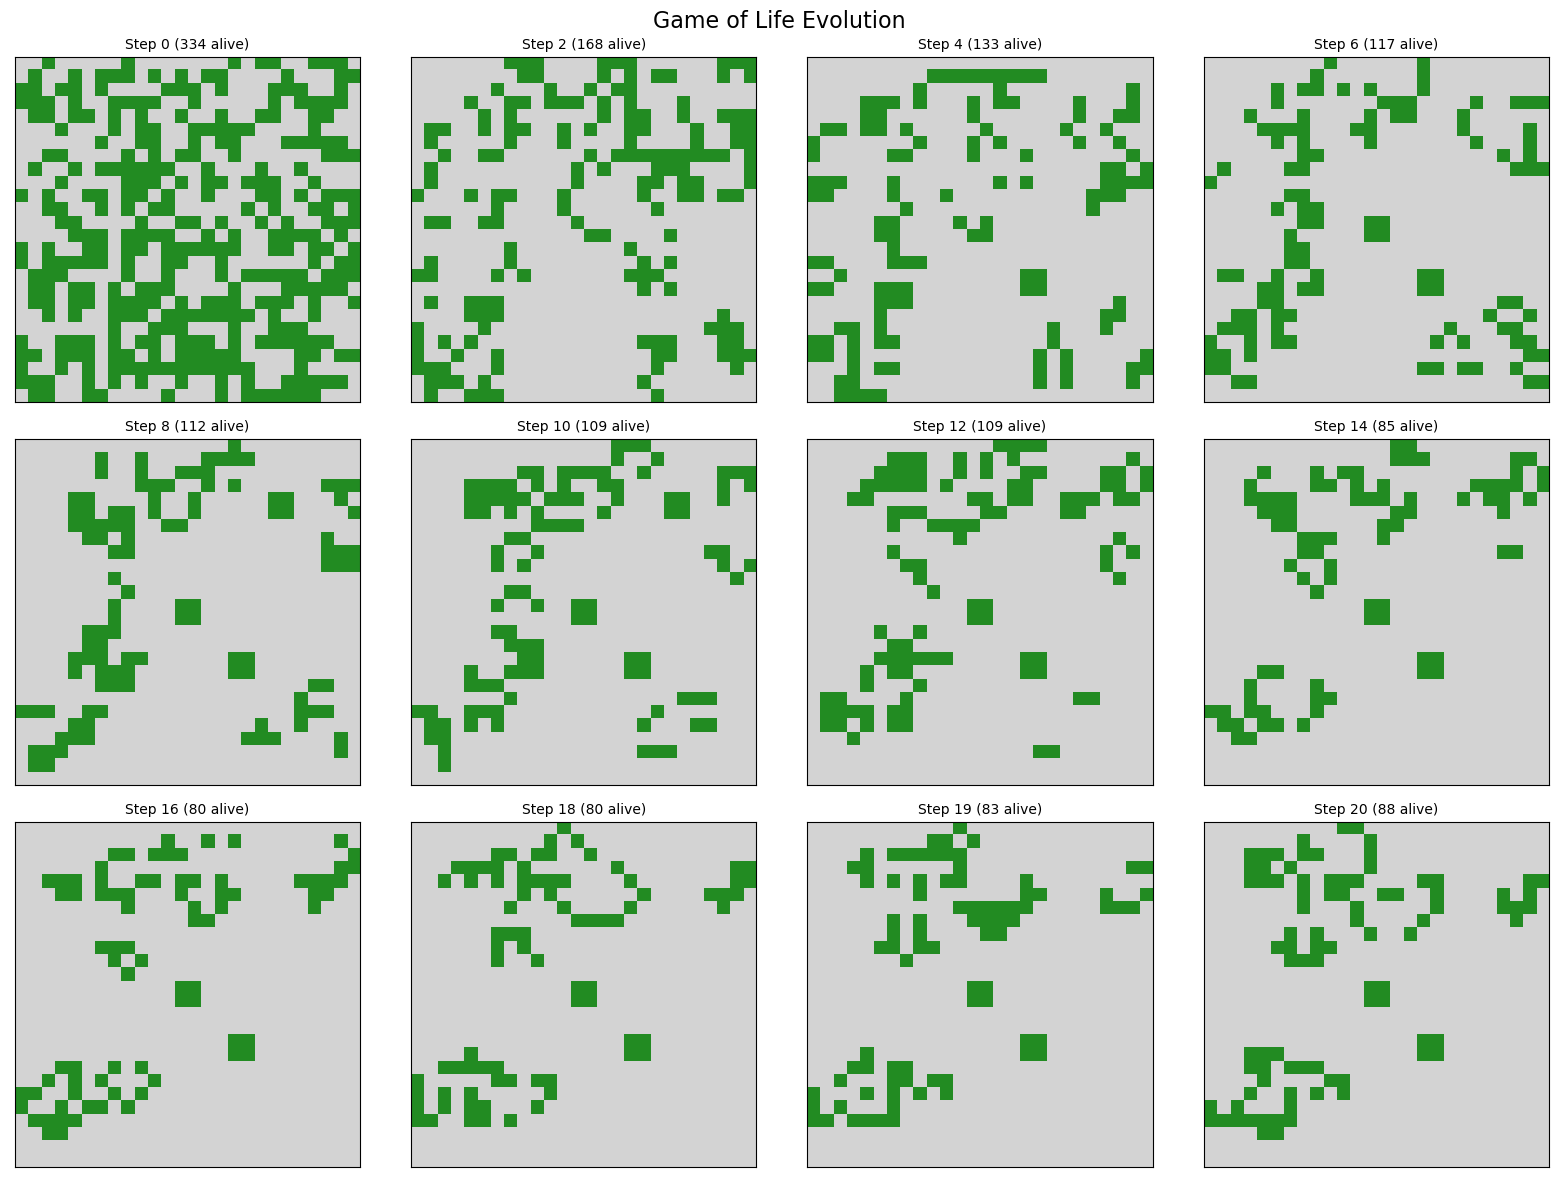

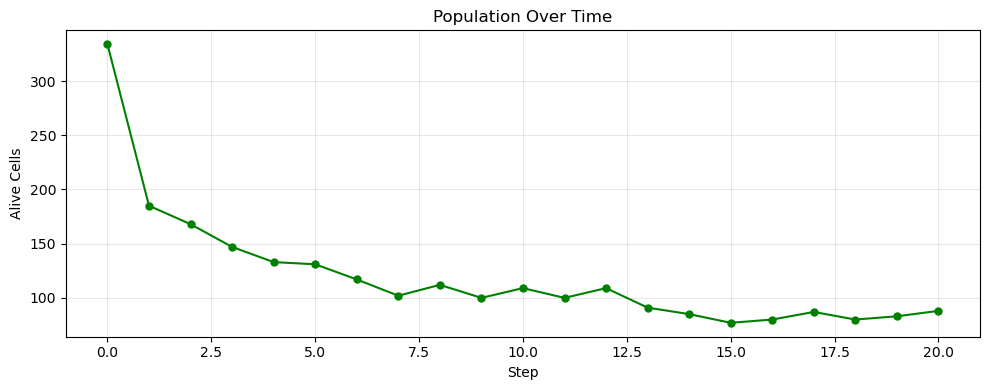

In [6]:
# візуалізація еволюції по кроках
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
cmap = mcolors.ListedColormap(['#D3D3D3', '#228B22'])

show_steps = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 19, 20]

for idx, step_num in enumerate(show_steps):
    ax = axes[idx // 4][idx % 4]
    ax.imshow(history[step_num], cmap=cmap, vmin=0, vmax=1)
    alive = sum(sum(row) for row in history[step_num])
    ax.set_title(f'Step {step_num} ({alive} alive)', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Game of Life Evolution', fontsize=16)
plt.tight_layout()
plt.show()

# графік популяції
alive_counts = [sum(sum(row) for row in h) for h in history]
plt.figure(figsize=(10, 4))
plt.plot(range(21), alive_counts, 'g-o', markersize=5)
plt.xlabel('Step')
plt.ylabel('Alive Cells')
plt.title('Population Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()